# Wikipedia Popularity Delta Analysis

This notebook analyzes the changes (deltas) in Wikipedia page popularity and rankings across years 2020-2023.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Force integer display - no float formatting
pd.options.display.float_format = '{:,.0f}'.format

## 1. Load Datasets

In [2]:
# Load all years
years = [2020, 2021, 2022, 2023]
data = {}

for year in years:
    file_path = f'data/popularity_table_{year}_avg.parquet'
    print(f"Loading {year}...")
    data[year] = pd.read_parquet(file_path)
    data[year] = data[year].dropna(subset=['popularity_avg'])
    print(f"  Shape: {data[year].shape}")
    print(f"  Columns: {data[year].columns.tolist()}")
    print()

Loading 2020...
  Shape: (5888983, 4)
  Columns: ['wikipedia_id', 'wikipedia_title', 'popularity_avg', 'rank_avg']

Loading 2021...
  Shape: (5860088, 4)
  Columns: ['wikipedia_id', 'wikipedia_title', 'popularity_avg', 'rank_avg']

Loading 2022...
  Shape: (5822790, 4)
  Columns: ['wikipedia_id', 'wikipedia_title', 'popularity_avg', 'rank_avg']

Loading 2023...
  Shape: (5805609, 4)
  Columns: ['wikipedia_id', 'wikipedia_title', 'popularity_avg', 'rank_avg']



In [3]:
# Display sample from 2020 data
print("Sample data from 2020:")
data[2020].head(10)

Sample data from 2020:


,wikipedia_id,wikipedia_title,popularity_avg,rank_avg
0,1000,Hercule Poirot,"65,156","13,146"
1,10000,Eiffel,841,"878,947"
2,10000001,Juan que reía,22,"4,463,454"
3,10000009,La Noche del hurto,30,"4,022,241"
4,1000001,NPU,"1,439","602,453"
5,10000010,Golden bear oil,24,"4,320,576"
6,10000012,No toquen a la nena,22,"4,441,488"
7,10000017,La Isla de los dibujos,22,"4,424,378"
8,1000002,Paul Davids,815,"912,833"
9,10000024,La Guerra de los sostenes,18,"4,680,798"


## 2. Calculate Year-over-Year Deltas

In [4]:
# Merge consecutive years to calculate deltas
deltas = {}

for i in range(len(years) - 1):
    year1, year2 = years[i], years[i+1]
    
    # Merge on wikipedia_id
    merged = data[year1].merge(
        data[year2],
        on=['wikipedia_id', 'wikipedia_title'],
        suffixes=(f'_{year1}', f'_{year2}')
    )
    
    # Calculate deltas
    merged[f'popularity_delta_{year1}_{year2}'] = merged[f'popularity_avg_{year2}'] - merged[f'popularity_avg_{year1}']
    merged[f'rank_delta_{year1}_{year2}'] = merged[f'rank_avg_{year2}'] - merged[f'rank_avg_{year1}']
    
    # Calculate percentage changes
    merged[f'popularity_pct_change_{year1}_{year2}'] = (
        (merged[f'popularity_avg_{year2}'] - merged[f'popularity_avg_{year1}']) / 
        merged[f'popularity_avg_{year1}'].replace(0, np.nan) * 100
    )
    
    deltas[f'{year1}_{year2}'] = merged
    
    print(f"Delta calculation for {year1} -> {year2}: {merged.shape[0]} pages")

print(f"\nTotal delta datasets created: {len(deltas)}")

Delta calculation for 2020 -> 2021: 5859419 pages
Delta calculation for 2021 -> 2022: 5820183 pages
Delta calculation for 2022 -> 2023: 5798113 pages

Total delta datasets created: 3


## 3. Summary Statistics

In [5]:
# Summary statistics for each year transition
for key, df in deltas.items():
    print(f"\n{'='*60}")
    print(f"DELTA STATISTICS: {key.replace('_', ' -> ')}")
    print(f"{'='*60}")
    
    year1, year2 = key.split('_')
    
    print(f"\nPopularity Delta ({year1} -> {year2}):")
    desc = df[f'popularity_delta_{year1}_{year2}'].describe()
    for idx, val in desc.items():
        print(f"{idx:>8}: {val:>15,.0f}")
    
    print(f"\nRank Delta ({year1} -> {year2}):")
    desc = df[f'rank_delta_{year1}_{year2}'].describe()
    for idx, val in desc.items():
        print(f"{idx:>8}: {val:>15,.0f}")
    
    print(f"\nPopularity % Change ({year1} -> {year2}):")
    desc = df[f'popularity_pct_change_{year1}_{year2}'].describe()
    for idx, val in desc.items():
        print(f"{idx:>8}: {val:>15,.0f}")


DELTA STATISTICS: 2020 -> 2021

Popularity Delta (2020 -> 2021):
   count:       5,859,419
    mean:            -105
     std:          22,080
     min:     -43,843,014
     25%:             -29
     50%:              -5
     75%:               0
     max:       2,761,289

Rank Delta (2020 -> 2021):
   count:       5,859,419
    mean:          -6,012
     std:         289,811
     min:      -5,220,478
     25%:        -122,495
     50%:         -11,432
     75%:          89,712
     max:       5,650,331

Popularity % Change (2020 -> 2021):
   count:       5,859,419
    mean:              -8
     std:             135
     min:            -100
     25%:             -28
     50%:             -14
     75%:               0
     max:         135,560

DELTA STATISTICS: 2021 -> 2022

Popularity Delta (2021 -> 2022):
   count:       5,820,183
    mean:             -59
     std:          10,753
     min:     -22,616,008
     25%:             -15
     50%:              -0
     75%:              

### 3.1 Corpus-Level Delta Statistics (Mean, Variance, Std Dev)

In [6]:
# Calculate corpus-level statistics
stats_data = []

for key, df in deltas.items():
    year1, year2 = key.split('_')
    
    stats_data.append({
        'Transition': f'{year1}→{year2}',
        'Pop_Mean': int(df[f'popularity_delta_{year1}_{year2}'].mean()),
        'Pop_Median': int(df[f'popularity_delta_{year1}_{year2}'].median()),
        'Pop_Std': int(df[f'popularity_delta_{year1}_{year2}'].std()),
        'Rank_Mean': int(df[f'rank_delta_{year1}_{year2}'].mean()),
        'Rank_Median': int(df[f'rank_delta_{year1}_{year2}'].median()),
        'Rank_Std': int(df[f'rank_delta_{year1}_{year2}'].std()),
    })

stats = pd.DataFrame(stats_data)

# Force integer display - no decimals
pd.options.display.float_format = '{:,.0f}'.format

# Display
print("\n" + "="*80)
print("CORPUS DELTA STATISTICS")
print("="*80)
print()
for idx, row in stats.iterrows():
    print(f"{row['Transition']:<15} Pop_Mean: {row['Pop_Mean']:>10,}   Pop_Median: {row['Pop_Median']:>10,}   Pop_Std: {row['Pop_Std']:>10,}")
    print(f"{'':15} Rank_Mean: {row['Rank_Mean']:>9,}   Rank_Median: {row['Rank_Median']:>9,}   Rank_Std: {row['Rank_Std']:>9,}")
    print()
print("="*80 + "\n")

stats


CORPUS DELTA STATISTICS

2020→2021       Pop_Mean:       -105   Pop_Median:         -5   Pop_Std:     22,080
                Rank_Mean:    -6,011   Rank_Median:   -11,432   Rank_Std:   289,810

2021→2022       Pop_Mean:        -59   Pop_Median:          0   Pop_Std:     10,753
                Rank_Mean:    -4,693   Rank_Median:    -6,123   Rank_Std:   270,265

2022→2023       Pop_Mean:         29   Pop_Median:          0   Pop_Std:      7,560
                Rank_Mean:    -3,068   Rank_Median:   -17,518   Rank_Std:   302,206




,Transition,Pop_Mean,Pop_Median,Pop_Std,Rank_Mean,Rank_Median,Rank_Std
0,2020→2021,-105,-5,22080,-6011,-11432,289810
1,2021→2022,-59,0,10753,-4693,-6123,270265
2,2022→2023,29,0,7560,-3068,-17518,302206


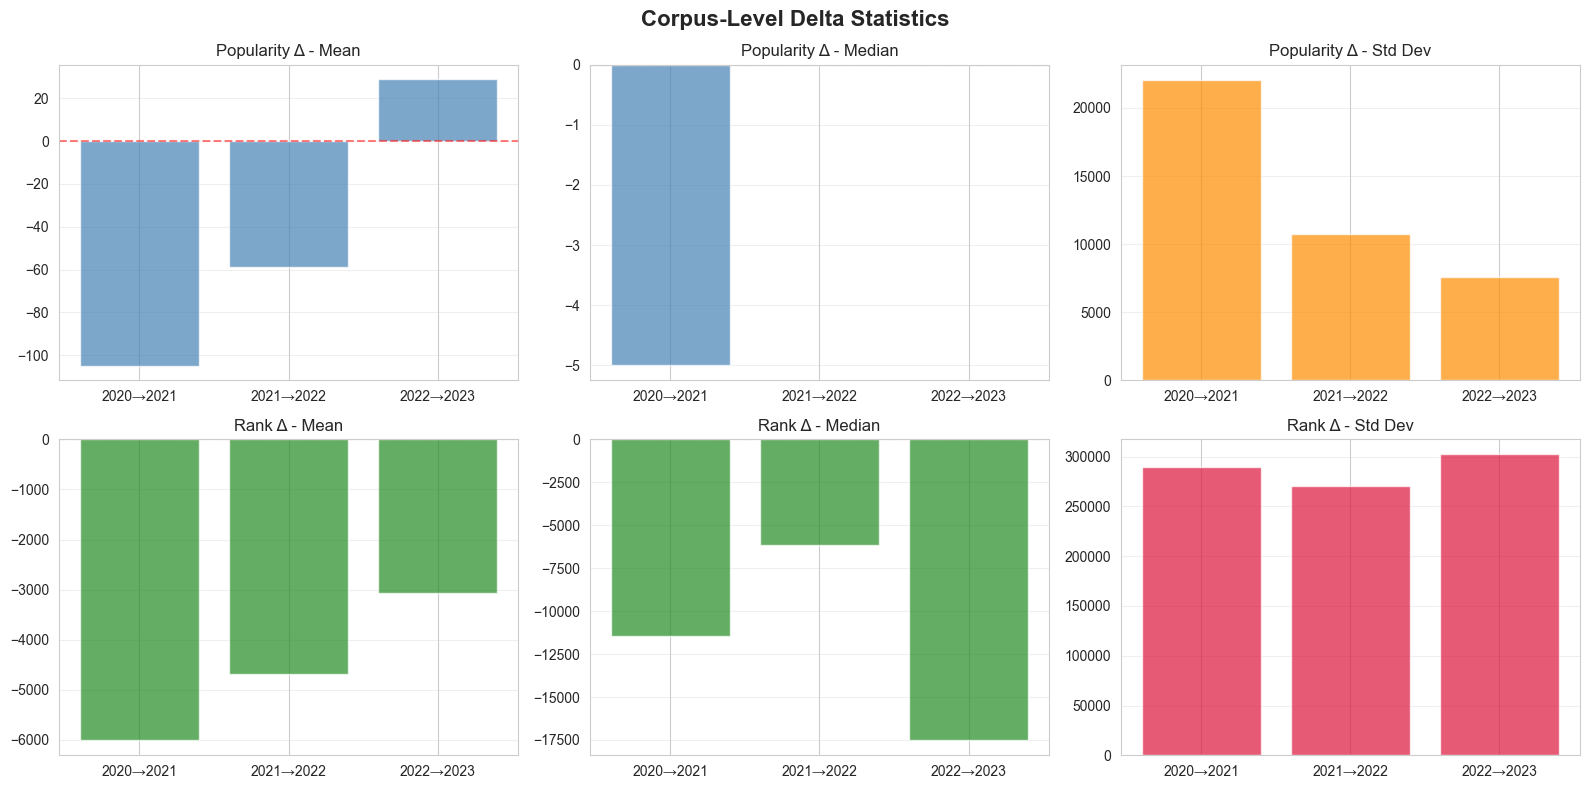

In [7]:
# Visualize statistics
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Corpus-Level Delta Statistics', fontsize=16, fontweight='bold')

# Popularity Delta
axes[0, 0].bar(stats['Transition'], stats['Pop_Mean'], color='steelblue', alpha=0.7)
axes[0, 0].set_title('Popularity Δ - Mean')
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].grid(True, alpha=0.3, axis='y')

axes[0, 1].bar(stats['Transition'], stats['Pop_Median'], color='steelblue', alpha=0.7)
axes[0, 1].set_title('Popularity Δ - Median')
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].grid(True, alpha=0.3, axis='y')

axes[0, 2].bar(stats['Transition'], stats['Pop_Std'], color='darkorange', alpha=0.7)
axes[0, 2].set_title('Popularity Δ - Std Dev')
axes[0, 2].grid(True, alpha=0.3, axis='y')

# Rank Delta
axes[1, 0].bar(stats['Transition'], stats['Rank_Mean'], color='forestgreen', alpha=0.7)
axes[1, 0].set_title('Rank Δ - Mean')
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].bar(stats['Transition'], stats['Rank_Median'], color='forestgreen', alpha=0.7)
axes[1, 1].set_title('Rank Δ - Median')
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].grid(True, alpha=0.3, axis='y')

axes[1, 2].bar(stats['Transition'], stats['Rank_Std'], color='crimson', alpha=0.7)
axes[1, 2].set_title('Rank Δ - Std Dev')
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Biggest Gainers and Losers

In [8]:
# Top gainers and losers by popularity for each year transition
for key, df in deltas.items():
    year1, year2 = key.split('_')
    delta_col = f'popularity_delta_{year1}_{year2}'
    
    print(f"\n{'='*80}")
    print(f"TOP 10 GAINERS: {year1} -> {year2}")
    print(f"{'='*80}")
    top_gainers = df.nlargest(10, delta_col)[[
        'wikipedia_title', 
        f'popularity_avg_{year1}', 
        f'popularity_avg_{year2}', 
        delta_col
    ]]
    print(top_gainers.to_string(index=False))
    
    print(f"\n{'='*80}")
    print(f"TOP 10 LOSERS: {year1} -> {year2}")
    print(f"{'='*80}")
    top_losers = df.nsmallest(10, delta_col)[[
        'wikipedia_title', 
        f'popularity_avg_{year1}', 
        f'popularity_avg_{year2}', 
        delta_col
    ]]
    print(top_losers.to_string(index=False))
    print()


TOP 10 GAINERS: 2020 -> 2021
          wikipedia_title  popularity_avg_2020  popularity_avg_2021  popularity_delta_2020_2021
                Cleopatra            1,059,382            3,820,671                   2,761,289
           UEFA Euro 2020              241,320            1,461,749                   1,220,429
            Skathi (moon)                8,446            1,211,446                   1,203,000
              Google logo               24,572            1,192,546                   1,167,973
     2020 Summer Olympics              274,869            1,217,513                     942,644
Webserver directory index               37,680              905,572                     867,892
      The Eternals (film)              238,415            1,065,036                     826,621
        Godzilla vs. Kong              152,011              976,524                     824,513
                       BF               65,593              874,831                     809,238
          

## 5. Visualizations

### 5.1 Distribution of Popularity Deltas

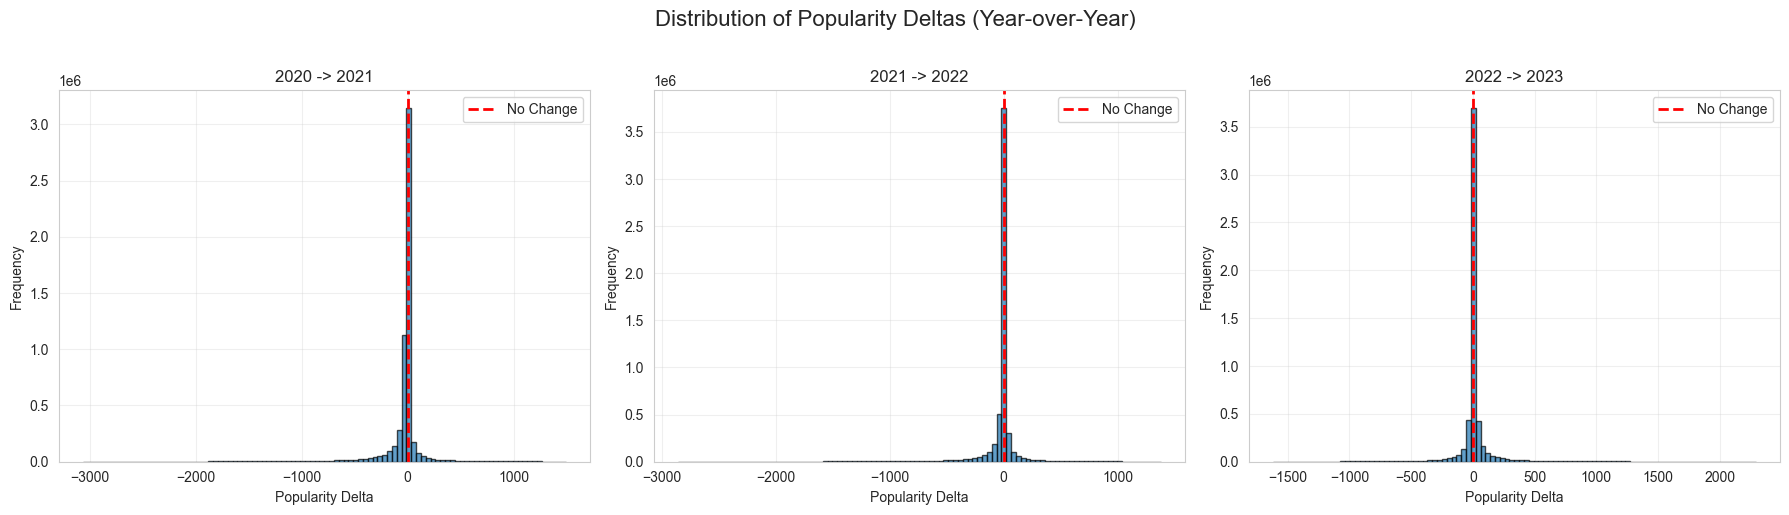

In [9]:
# Plot distribution of popularity deltas for each year transition
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Popularity Deltas (Year-over-Year)', fontsize=16, y=1.02)

for idx, (key, df) in enumerate(deltas.items()):
    year1, year2 = key.split('_')
    delta_col = f'popularity_delta_{year1}_{year2}'
    
    # Filter extreme outliers for better visualization
    q1, q99 = df[delta_col].quantile([0.01, 0.99])
    filtered_data = df[delta_col][(df[delta_col] >= q1) & (df[delta_col] <= q99)]
    
    axes[idx].hist(filtered_data, bins=100, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{year1} -> {year2}')
    axes[idx].set_xlabel('Popularity Delta')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Change')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Distribution of Rank Deltas

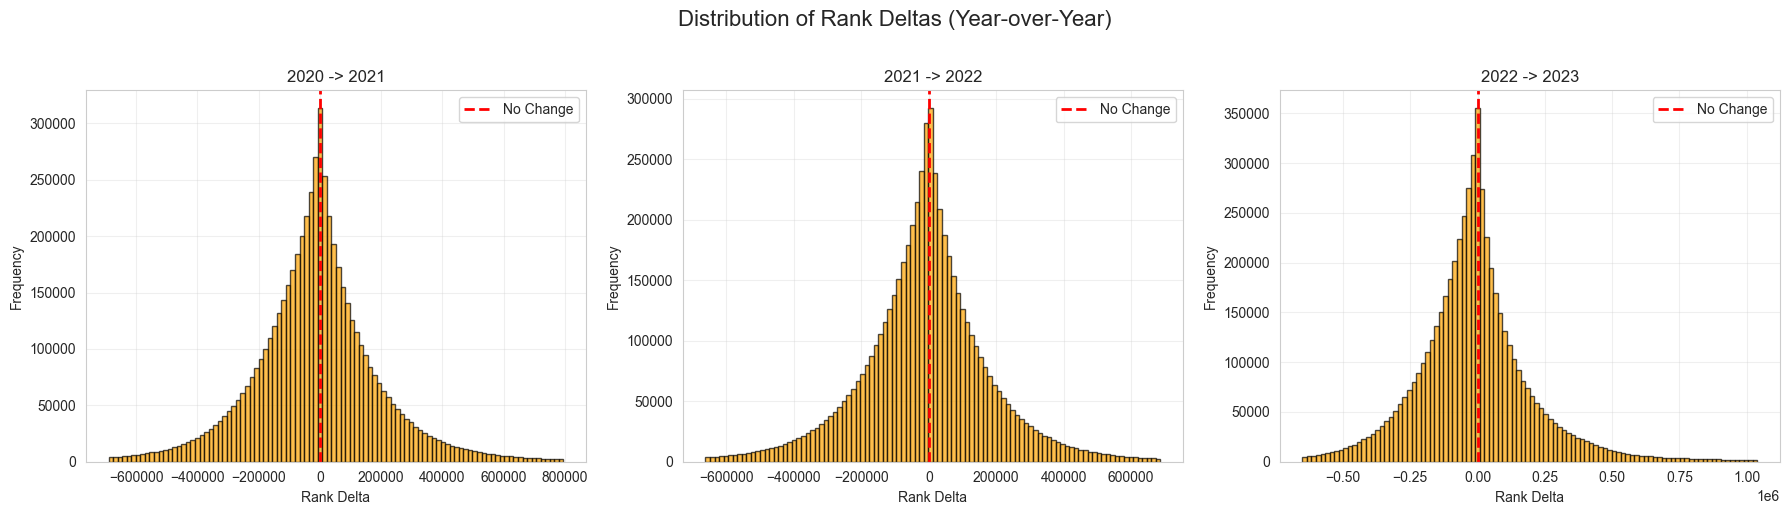

In [10]:
# Plot distribution of rank deltas for each year transition
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Rank Deltas (Year-over-Year)', fontsize=16, y=1.02)

for idx, (key, df) in enumerate(deltas.items()):
    year1, year2 = key.split('_')
    delta_col = f'rank_delta_{year1}_{year2}'
    
    # Filter extreme outliers for better visualization
    q1, q99 = df[delta_col].quantile([0.01, 0.99])
    filtered_data = df[delta_col][(df[delta_col] >= q1) & (df[delta_col] <= q99)]
    
    axes[idx].hist(filtered_data, bins=100, edgecolor='black', alpha=0.7, color='orange')
    axes[idx].set_title(f'{year1} -> {year2}')
    axes[idx].set_xlabel('Rank Delta')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Change')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4 Box Plots: Delta Comparisons

/var/folders/14/7y09r8b90rd3t_63ryrt3b1r0000gn/T/ipykernel_44569/3733760440.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(pop_delta_data, labels=labels)
/var/folders/14/7y09r8b90rd3t_63ryrt3b1r0000gn/T/ipykernel_44569/3733760440.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(rank_delta_data, labels=labels)


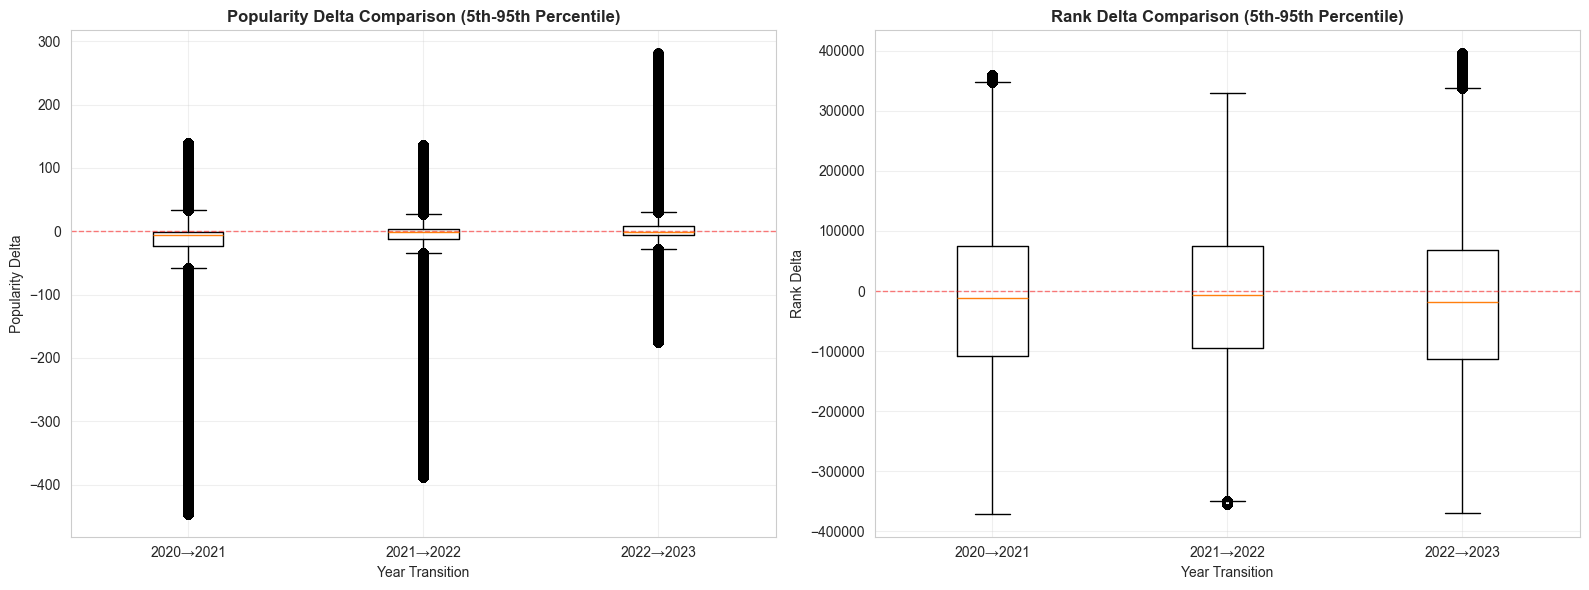

In [11]:
# Box plots comparing deltas across years
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data for box plots
pop_delta_data = []
rank_delta_data = []
labels = []

for key, df in deltas.items():
    year1, year2 = key.split('_')
    labels.append(f'{year1}→{year2}')
    
    pop_delta_col = f'popularity_delta_{year1}_{year2}'
    rank_delta_col = f'rank_delta_{year1}_{year2}'
    
    # Filter outliers for better visualization
    q1, q99 = df[pop_delta_col].quantile([0.05, 0.95])
    pop_delta_data.append(df[pop_delta_col][(df[pop_delta_col] >= q1) & (df[pop_delta_col] <= q99)])
    
    q1, q99 = df[rank_delta_col].quantile([0.05, 0.95])
    rank_delta_data.append(df[rank_delta_col][(df[rank_delta_col] >= q1) & (df[rank_delta_col] <= q99)])

# Popularity delta box plot
axes[0].boxplot(pop_delta_data, labels=labels)
axes[0].set_title('Popularity Delta Comparison (5th-95th Percentile)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year Transition')
axes[0].set_ylabel('Popularity Delta')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0].grid(True, alpha=0.3)

# Rank delta box plot
axes[1].boxplot(rank_delta_data, labels=labels)
axes[1].set_title('Rank Delta Comparison (5th-95th Percentile)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year Transition')
axes[1].set_ylabel('Rank Delta')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.5 Percentage Change Analysis

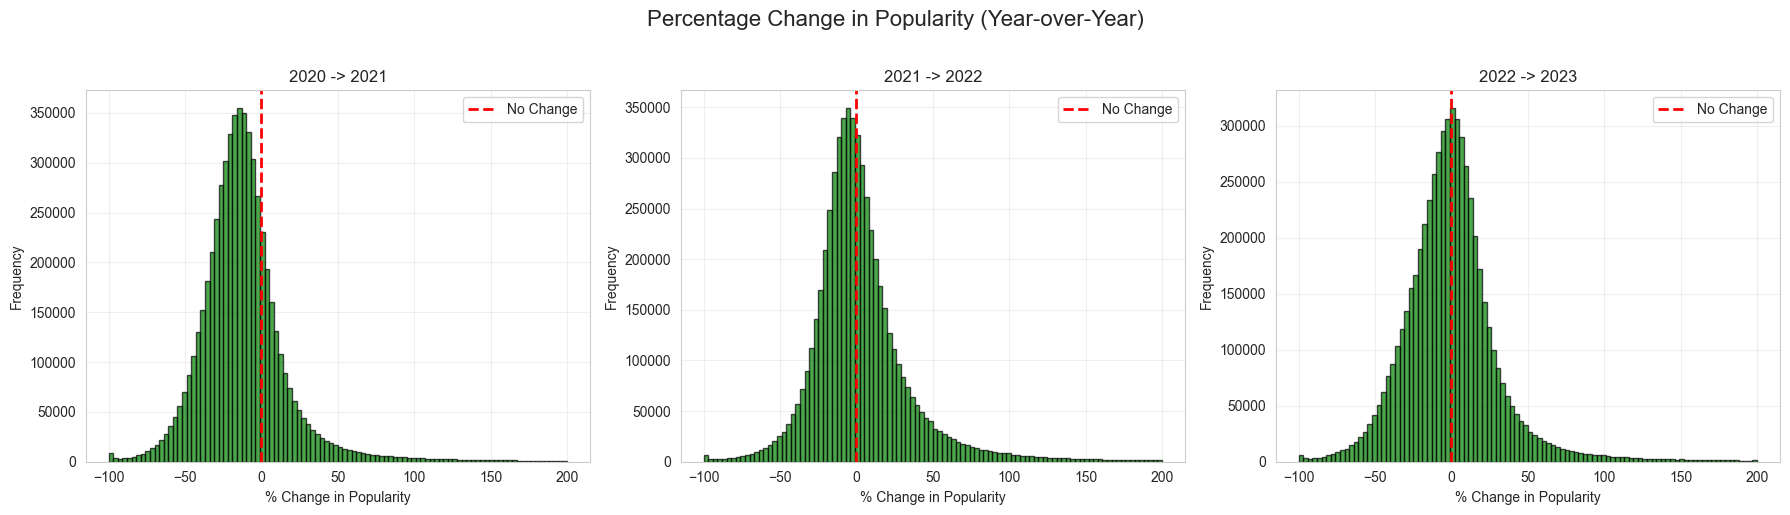

In [12]:
# Distribution of percentage changes in popularity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Percentage Change in Popularity (Year-over-Year)', fontsize=16, y=1.02)

for idx, (key, df) in enumerate(deltas.items()):
    year1, year2 = key.split('_')
    pct_col = f'popularity_pct_change_{year1}_{year2}'
    
    # Filter extreme outliers and NaN values
    filtered_data = df[pct_col].dropna()
    filtered_data = filtered_data[(filtered_data >= -200) & (filtered_data <= 200)]
    
    axes[idx].hist(filtered_data, bins=100, edgecolor='black', alpha=0.7, color='green')
    axes[idx].set_title(f'{year1} -> {year2}')
    axes[idx].set_xlabel('% Change in Popularity')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Change')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.7 Time Series: Average Metrics Across Years

In [13]:
# Calculate average metrics for each year
avg_metrics = pd.DataFrame({
    'Year': years,
    'Avg_Popularity': [data[year]['popularity_avg'].mean() for year in years],
    'Median_Popularity': [data[year]['popularity_avg'].median() for year in years],
    'Avg_Rank': [data[year]['rank_avg'].mean() for year in years],
    'Median_Rank': [data[year]['rank_avg'].median() for year in years]
})

print(avg_metrics)
print()

   Year  Avg_Popularity  Median_Popularity  Avg_Rank  Median_Rank
0  2020           1,238                 76 2,944,560    2,968,122
1  2021           1,138                 66 2,930,323    2,953,151
2  2022           1,085                 64 2,911,866    2,939,926
3  2023           1,117                 65 2,903,777    2,929,888



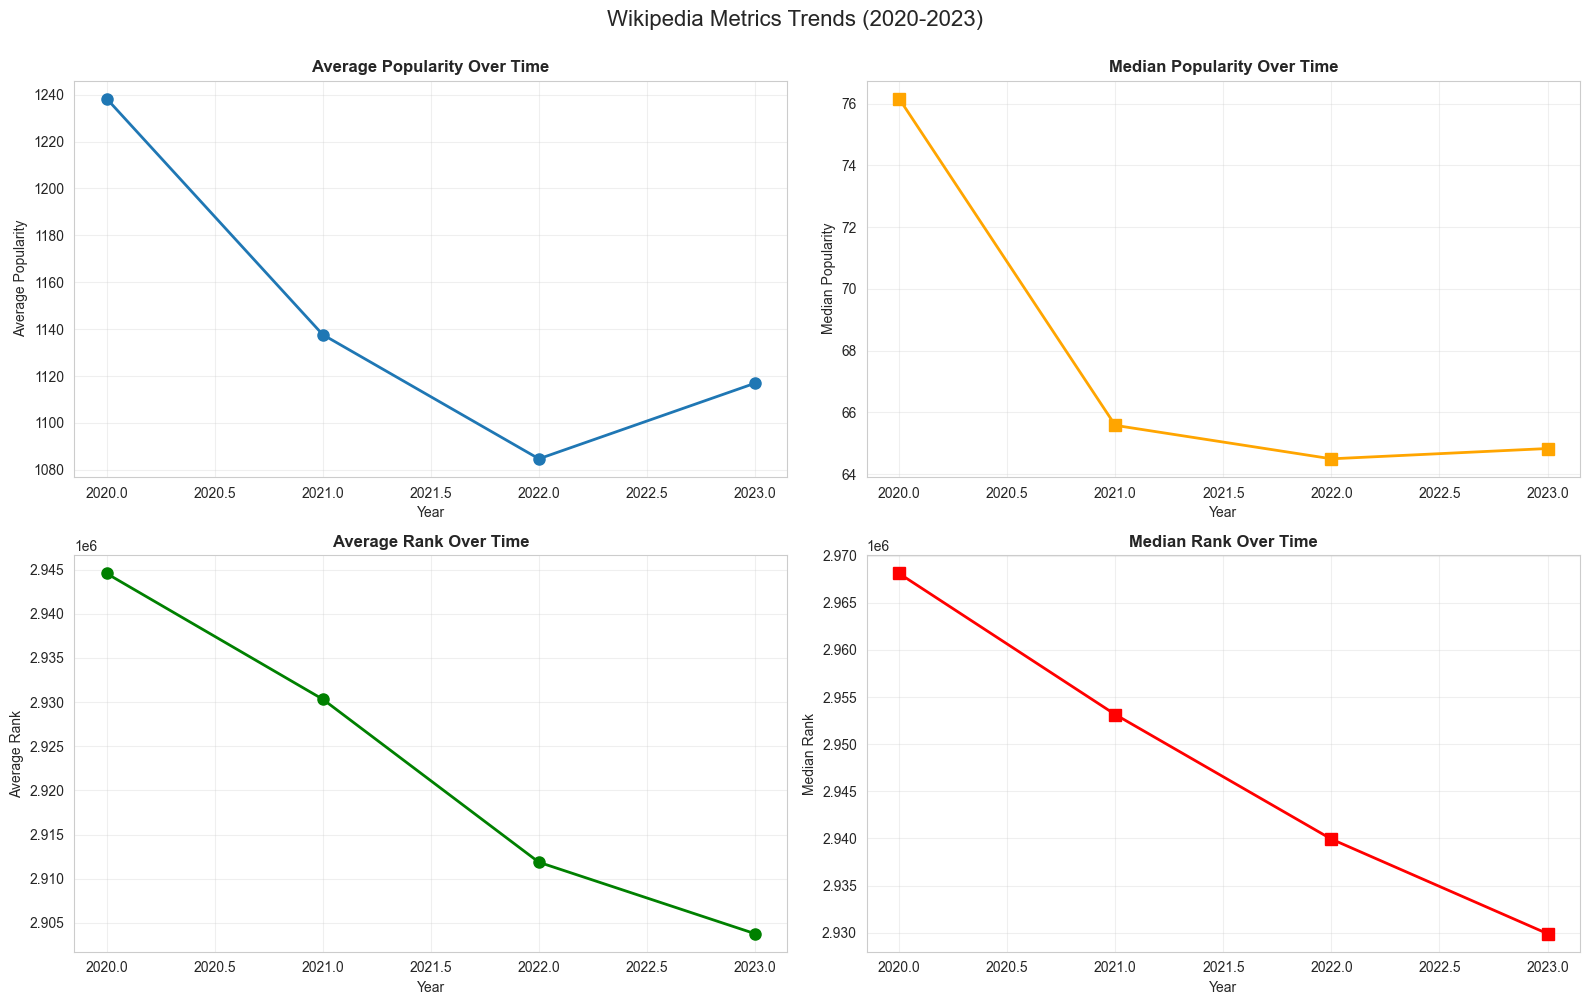

In [14]:
# Plot time series of average metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Wikipedia Metrics Trends (2020-2023)', fontsize=16, y=1.00)

# Average popularity
axes[0, 0].plot(avg_metrics['Year'], avg_metrics['Avg_Popularity'], marker='o', linewidth=2, markersize=8)
axes[0, 0].set_title('Average Popularity Over Time', fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Average Popularity')
axes[0, 0].grid(True, alpha=0.3)

# Median popularity
axes[0, 1].plot(avg_metrics['Year'], avg_metrics['Median_Popularity'], marker='s', linewidth=2, markersize=8, color='orange')
axes[0, 1].set_title('Median Popularity Over Time', fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Median Popularity')
axes[0, 1].grid(True, alpha=0.3)

# Average rank
axes[1, 0].plot(avg_metrics['Year'], avg_metrics['Avg_Rank'], marker='o', linewidth=2, markersize=8, color='green')
axes[1, 0].set_title('Average Rank Over Time', fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Average Rank')
axes[1, 0].grid(True, alpha=0.3)

# Median rank
axes[1, 1].plot(avg_metrics['Year'], avg_metrics['Median_Rank'], marker='s', linewidth=2, markersize=8, color='red')
axes[1, 1].set_title('Median Rank Over Time', fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Median Rank')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Additional Analysis: Stability Metrics

In [15]:
# Calculate what percentage of pages gained vs lost popularity
for key, df in deltas.items():
    year1, year2 = key.split('_')
    delta_col = f'popularity_delta_{year1}_{year2}'
    
    gained = (df[delta_col] > 0).sum()
    lost = (df[delta_col] < 0).sum()
    unchanged = (df[delta_col] == 0).sum()
    total = len(df)
    
    print(f"\n{year1} -> {year2}:")
    print(f"  Gained popularity: {gained:,} ({gained/total*100:.2f}%)")
    print(f"  Lost popularity: {lost:,} ({lost/total*100:.2f}%)")
    print(f"  Unchanged: {unchanged:,} ({unchanged/total*100:.2f}%)")


2020 -> 2021:
  Gained popularity: 1,458,363 (24.89%)
  Lost popularity: 4,384,592 (74.83%)
  Unchanged: 16,464 (0.28%)

2021 -> 2022:
  Gained popularity: 2,699,977 (46.39%)
  Lost popularity: 3,089,583 (53.08%)
  Unchanged: 30,623 (0.53%)

2022 -> 2023:
  Gained popularity: 2,732,197 (47.12%)
  Lost popularity: 3,039,282 (52.42%)
  Unchanged: 26,634 (0.46%)


## 8. Decile Movement Analysis

Analyzing how pages move between popularity deciles (10 equal-sized groups) across years.

In [16]:
# Create deciles for each year and track movements
def assign_deciles(df, popularity_col):
    """Assign decile labels (1-10) based on popularity"""
    return pd.qcut(df[popularity_col], q=10, labels=range(1, 11), duplicates='drop')

# Add decile assignments to each year's data
for year in years:
    data[year]['decile'] = assign_deciles(data[year], 'popularity_avg')
    print(f"{year}: Deciles assigned")

print("\nDecile ranges for 2020:")
print(data[2020].groupby('decile')['popularity_avg'].agg(['min', 'max', 'count']))

2020: Deciles assigned
2021: Deciles assigned
2022: Deciles assigned
2023: Deciles assigned

Decile ranges for 2020:
         min         max   count
decile                          
1          1          10  591358
2         10          17  591377
3         17          29  586612
4         29          46  586575
5         46          76  588805
6         76         130  588945
7        130         240  588655
8        240         510  588899
9        510       1,525  588865
10     1,525 222,893,628  588892


/var/folders/14/7y09r8b90rd3t_63ryrt3b1r0000gn/T/ipykernel_44569/1209394658.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data[2020].groupby('decile')['popularity_avg'].agg(['min', 'max', 'count']))


### 8.1 Transition Matrices

In [17]:
# Create transition matrices showing movement between deciles
transition_matrices = {}

for key, df in deltas.items():
    year1, year2 = key.split('_')
    
    # Merge with decile information
    df_with_deciles = df.merge(
        data[int(year1)][['wikipedia_id', 'decile']],
        on='wikipedia_id',
        how='left'
    ).rename(columns={'decile': f'decile_{year1}'})
    
    df_with_deciles = df_with_deciles.merge(
        data[int(year2)][['wikipedia_id', 'decile']],
        on='wikipedia_id',
        how='left'
    ).rename(columns={'decile': f'decile_{year2}'})
    
    # Create transition matrix (counts)
    transition = pd.crosstab(
        df_with_deciles[f'decile_{year1}'],
        df_with_deciles[f'decile_{year2}'],
        normalize=False
    )
    
    # Create normalized transition matrix (percentages)
    transition_pct = pd.crosstab(
        df_with_deciles[f'decile_{year1}'],
        df_with_deciles[f'decile_{year2}'],
        normalize='index'
    ) * 100
    
    transition_matrices[key] = {
        'counts': transition,
        'percentages': transition_pct,
        'data': df_with_deciles
    }
    
    print(f"\n{'='*70}")
    print(f"TRANSITION MATRIX: {year1} -> {year2} (Row %)")
    print(f"{'='*70}")
    print("Rows = Starting Decile, Columns = Ending Decile")
    print(transition_pct.round(1))
    print()


TRANSITION MATRIX: 2020 -> 2021 (Row %)
Rows = Starting Decile, Columns = Ending Decile
decile_2021  1  2  3  4  5  6  7  8  9  10
decile_2020                               
1           84 15  1  0  0  0  0  0  0   0
2           14 66 18  1  0  0  0  0  0   0
3            1 16 62 18  2  0  0  0  0   0
4            0  1 17 62 18  2  0  0  0   0
5            0  0  2 17 62 16  2  0  0   0
6            0  0  0  2 16 65 15  1  0   0
7            0  0  0  0  2 15 68 13  1   0
8            0  0  0  0  0  2 14 72 11   0
9            0  0  0  0  0  0  1 12 79   7
10           0  0  0  0  0  0  0  0  8  92


TRANSITION MATRIX: 2021 -> 2022 (Row %)
Rows = Starting Decile, Columns = Ending Decile
decile_2022  1  2  3  4  5  6  7  8  9  10
decile_2021                               
1           84 13  2  0  0  0  0  0  0   0
2           14 67 16  2  0  0  0  0  0   0
3            1 19 62 17  2  0  0  0  0   0
4            0  1 19 62 16  1  0  0  0   0
5            0  0  1 18 64 15  1  0  0   0
6   

### 8.2 Visualize Transition Matrices

In [18]:
# Calculate detailed movement statistics
movement_stats = []

for key, matrices in transition_matrices.items():
    year1, year2 = key.split('_')
    df_with_deciles = matrices['data']
    
    # Calculate movement
    df_with_deciles['decile_change'] = df_with_deciles[f'decile_{year2}'].astype(int) - df_with_deciles[f'decile_{year1}'].astype(int)
    
    total = len(df_with_deciles)
    stayed_same = (df_with_deciles['decile_change'] == 0).sum()
    moved_up = (df_with_deciles['decile_change'] > 0).sum()
    moved_down = (df_with_deciles['decile_change'] < 0).sum()
    
    # Calculate average absolute movement
    avg_abs_movement = df_with_deciles['decile_change'].abs().mean()
    
    # Calculate how many moved 2+ deciles
    moved_2plus_up = (df_with_deciles['decile_change'] >= 2).sum()
    moved_2plus_down = (df_with_deciles['decile_change'] <= -2).sum()
    
    # Calculate how many moved 5+ deciles (extreme movement)
    moved_5plus_up = (df_with_deciles['decile_change'] >= 5).sum()
    moved_5plus_down = (df_with_deciles['decile_change'] <= -5).sum()
    
    movement_stats.append({
        'Transition': f'{year1}→{year2}',
        'Total Pages': total,
        'Stayed Same': stayed_same,
        'Stayed Same %': stayed_same / total * 100,
        'Moved Up': moved_up,
        'Moved Up %': moved_up / total * 100,
        'Moved Down': moved_down,
        'Moved Down %': moved_down / total * 100,
        'Avg Abs Movement': avg_abs_movement,
        'Moved 2+ Up': moved_2plus_up,
        'Moved 2+ Up %': moved_2plus_up / total * 100,
        'Moved 2+ Down': moved_2plus_down,
        'Moved 2+ Down %': moved_2plus_down / total * 100,
        'Moved 5+ Up': moved_5plus_up,
        'Moved 5+ Up %': moved_5plus_up / total * 100,
        'Moved 5+ Down': moved_5plus_down,
        'Moved 5+ Down %': moved_5plus_down / total * 100,
    })

movement_df = pd.DataFrame(movement_stats)

print("\n" + "="*90)
print("DECILE MOVEMENT STATISTICS")
print("="*90)

for _, row in movement_df.iterrows():
    print(f"\n{row['Transition']}")
    print(f"  Total pages:           {int(row['Total Pages']):>12,}")
    print(f"  Stayed in same decile: {int(row['Stayed Same']):>12,} ({row['Stayed Same %']:>5.1f}%)")
    print(f"  Moved up:              {int(row['Moved Up']):>12,} ({row['Moved Up %']:>5.1f}%)")
    print(f"  Moved down:            {int(row['Moved Down']):>12,} ({row['Moved Down %']:>5.1f}%)")
    print(f"  Avg absolute movement: {row['Avg Abs Movement']:>12.2f} deciles")
    print(f"  Moved 2+ deciles up:   {int(row['Moved 2+ Up']):>12,} ({row['Moved 2+ Up %']:>5.1f}%)")
    print(f"  Moved 2+ deciles down: {int(row['Moved 2+ Down']):>12,} ({row['Moved 2+ Down %']:>5.1f}%)")
    print(f"  Moved 5+ deciles up:   {int(row['Moved 5+ Up']):>12,} ({row['Moved 5+ Up %']:>5.1f}%)")
    print(f"  Moved 5+ deciles down: {int(row['Moved 5+ Down']):>12,} ({row['Moved 5+ Down %']:>5.1f}%)")

print("\n" + "="*90)


DECILE MOVEMENT STATISTICS

2020→2021
  Total pages:              5,859,419
  Stayed in same decile:    4,170,779 ( 71.2%)
  Moved up:                   850,918 ( 14.5%)
  Moved down:                 837,722 ( 14.3%)
  Avg absolute movement:         0.33 deciles
  Moved 2+ deciles up:         74,083 (  1.3%)
  Moved 2+ deciles down:       82,313 (  1.4%)
  Moved 5+ deciles up:          1,759 (  0.0%)
  Moved 5+ deciles down:        7,887 (  0.1%)

2021→2022
  Total pages:              5,820,183
  Stayed in same decile:    4,205,328 ( 72.3%)
  Moved up:                   772,152 ( 13.3%)
  Moved down:                 842,703 ( 14.5%)
  Avg absolute movement:         0.32 deciles
  Moved 2+ deciles up:         81,634 (  1.4%)
  Moved 2+ deciles down:       66,825 (  1.1%)
  Moved 5+ deciles up:          1,833 (  0.0%)
  Moved 5+ deciles down:        6,892 (  0.1%)

2022→2023
  Total pages:              5,798,113
  Stayed in same decile:    4,165,404 ( 71.8%)
  Moved up:                 

### 8.3 Movement Statistics

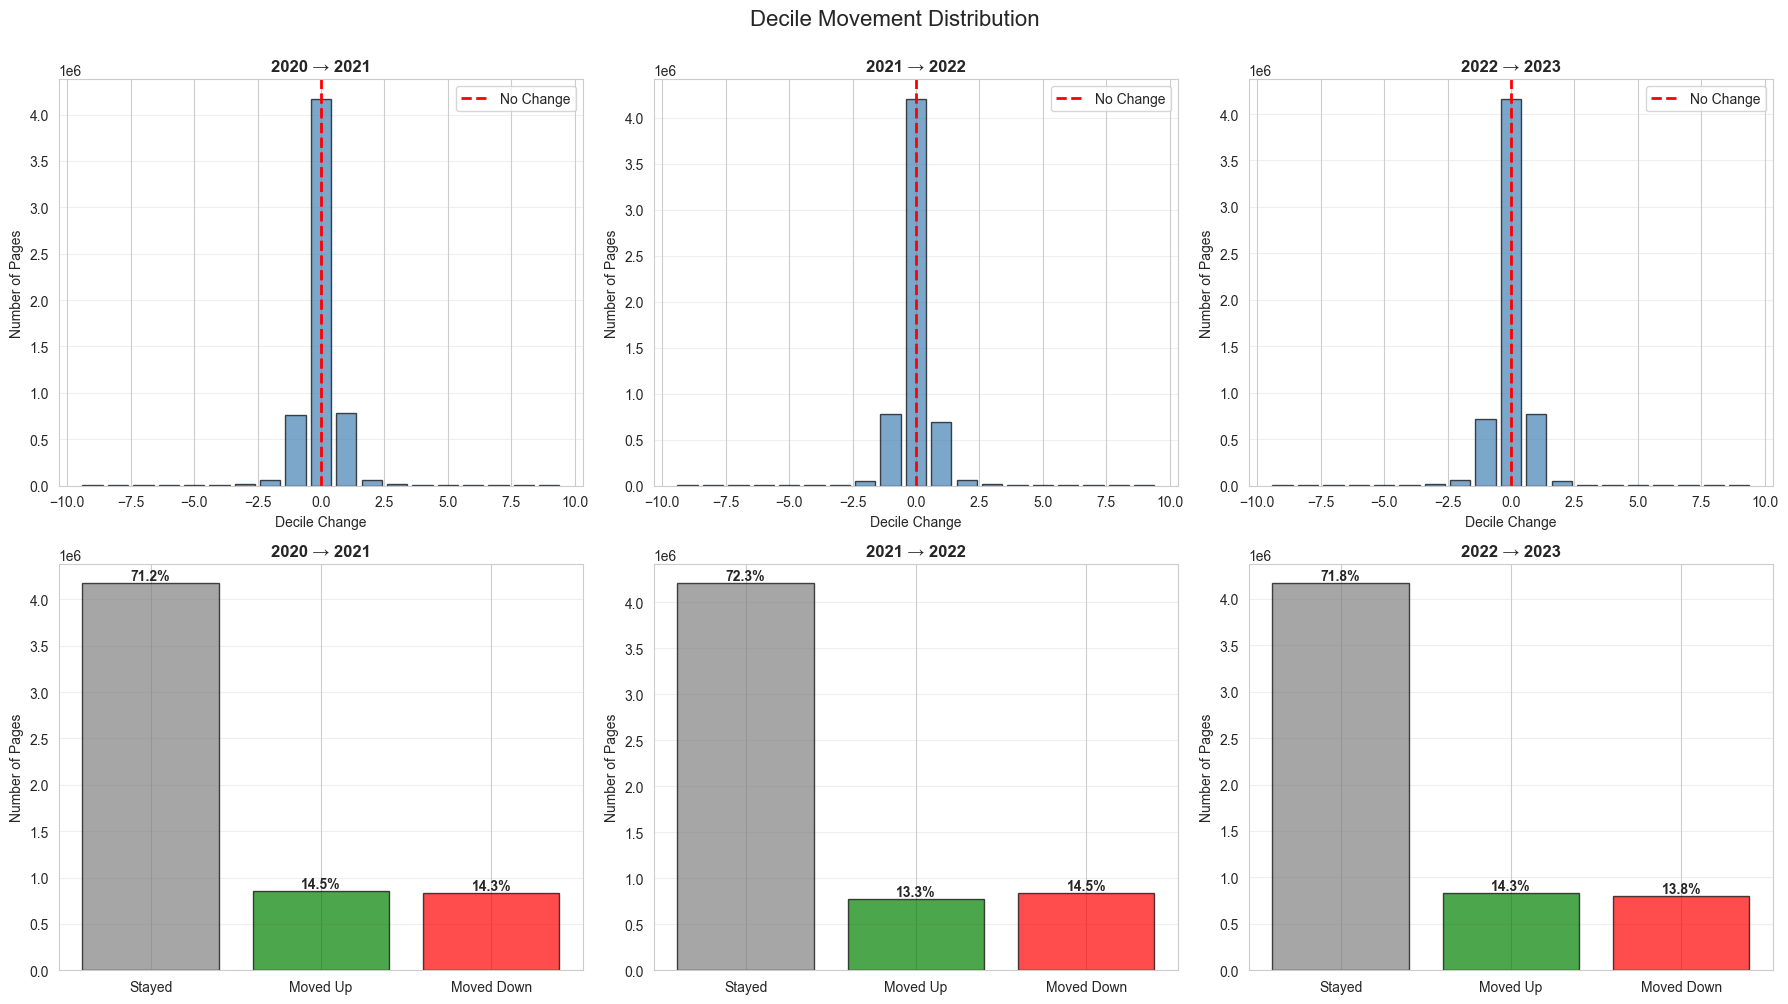

In [19]:
# Visualize the distribution of decile changes
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Decile Movement Distribution', fontsize=16, y=1.00)

for idx, (key, matrices) in enumerate(transition_matrices.items()):
    year1, year2 = key.split('_')
    df_with_deciles = matrices['data']
    
    # Histogram of decile changes
    ax = axes[0, idx]
    decile_changes = df_with_deciles['decile_change'].value_counts().sort_index()
    ax.bar(decile_changes.index, decile_changes.values, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_title(f'{year1} → {year2}', fontweight='bold')
    ax.set_xlabel('Decile Change')
    ax.set_ylabel('Number of Pages')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Change')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend()
    
    # Stacked bar: stayed/up/down
    ax2 = axes[1, idx]
    stayed = (df_with_deciles['decile_change'] == 0).sum()
    up = (df_with_deciles['decile_change'] > 0).sum()
    down = (df_with_deciles['decile_change'] < 0).sum()
    
    categories = ['Stayed', 'Moved Up', 'Moved Down']
    values = [stayed, up, down]
    colors = ['gray', 'green', 'red']
    
    ax2.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
    ax2.set_title(f'{year1} → {year2}', fontweight='bold')
    ax2.set_ylabel('Number of Pages')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add percentages on bars
    total = len(df_with_deciles)
    for i, (cat, val) in enumerate(zip(categories, values)):
        pct = val / total * 100
        ax2.text(i, val, f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### 8.4 Visualize Movement Distribution

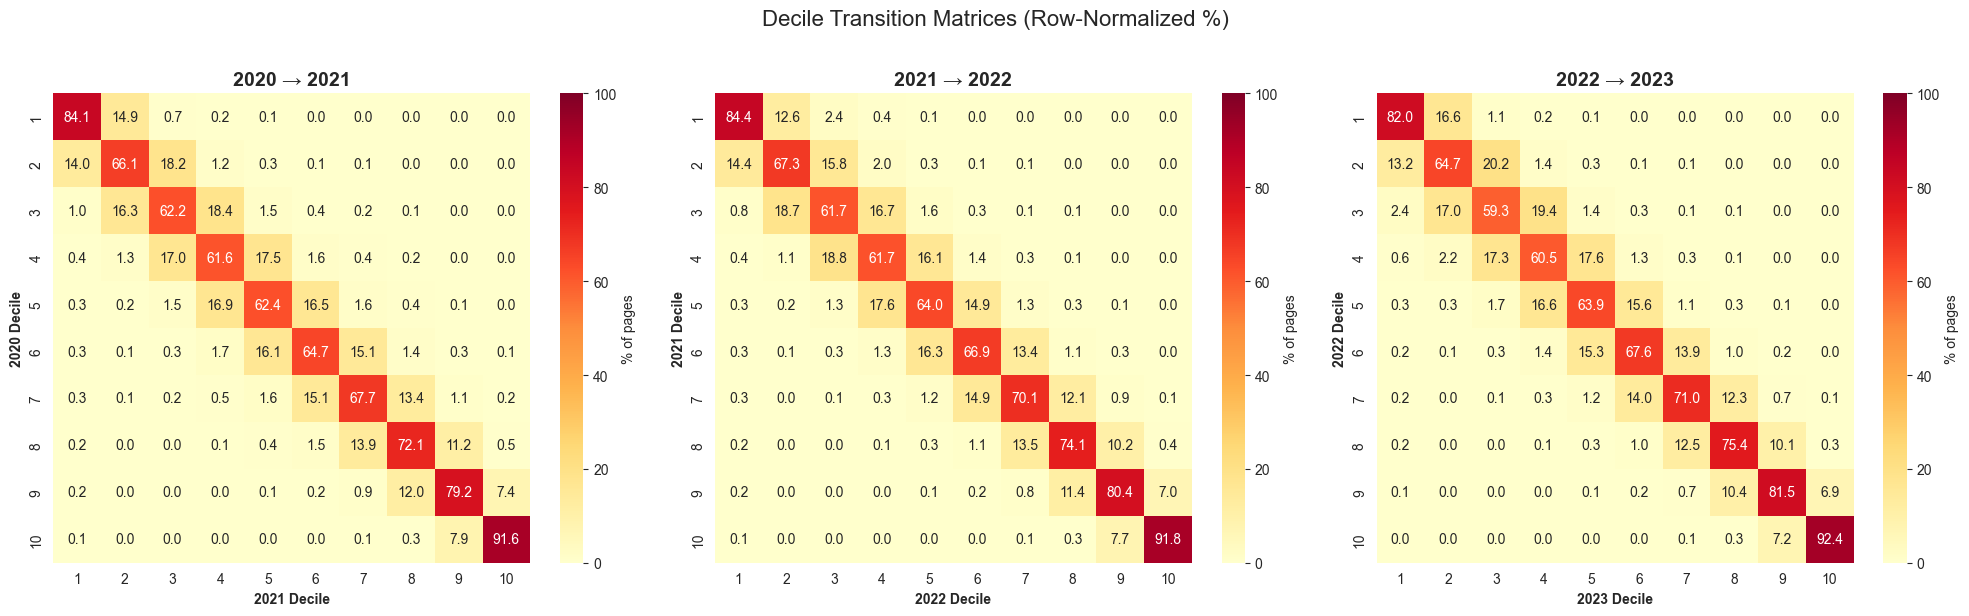

In [20]:
# Visualize transition matrices as heatmaps
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Decile Transition Matrices (Row-Normalized %)', fontsize=16, y=1.02)

for idx, (key, matrices) in enumerate(transition_matrices.items()):
    year1, year2 = key.split('_')
    
    sns.heatmap(
        matrices['percentages'],
        annot=True,
        fmt='.1f',
        cmap='YlOrRd',
        cbar_kws={'label': '% of pages'},
        ax=axes[idx],
        vmin=0,
        vmax=100
    )
    
    axes[idx].set_title(f'{year1} → {year2}', fontweight='bold', fontsize=14)
    axes[idx].set_xlabel(f'{year2} Decile', fontweight='bold')
    axes[idx].set_ylabel(f'{year1} Decile', fontweight='bold')

plt.tight_layout()
plt.show()

### 8.5 Stability by Decile

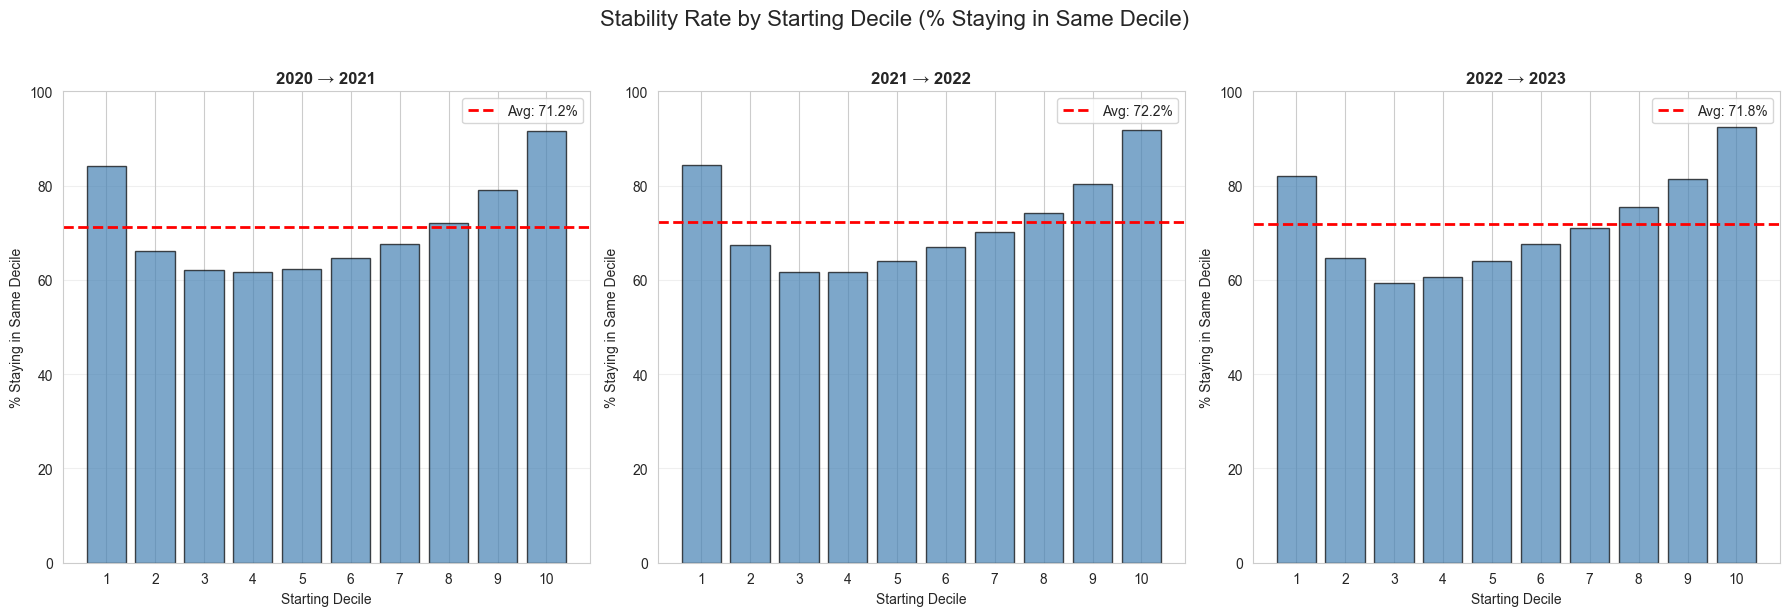

In [21]:
# Analyze stability by starting decile - which deciles are most stable?
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Stability Rate by Starting Decile (% Staying in Same Decile)', fontsize=16, y=1.02)

for idx, (key, matrices) in enumerate(transition_matrices.items()):
    year1, year2 = key.split('_')
    
    # Calculate % staying in same decile for each starting decile
    stability = []
    for decile in range(1, 11):
        if decile in matrices['percentages'].index:
            stayed_pct = matrices['percentages'].loc[decile, decile]
            stability.append(stayed_pct)
        else:
            stability.append(0)
    
    axes[idx].bar(range(1, 11), stability, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{year1} → {year2}', fontweight='bold')
    axes[idx].set_xlabel('Starting Decile')
    axes[idx].set_ylabel('% Staying in Same Decile')
    axes[idx].set_xticks(range(1, 11))
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].set_ylim(0, 100)
    
    # Add average line
    avg_stability = sum(stability) / len(stability)
    axes[idx].axhline(y=avg_stability, color='red', linestyle='--', linewidth=2, 
                      label=f'Avg: {avg_stability:.1f}%')
    axes[idx].legend()

plt.tight_layout()
plt.show()

## 9. Export Delta Data (Optional)

In [22]:
# Optionally save delta datasets and transition matrices to files
save_deltas = False  # Set to True if you want to save

if save_deltas:
    for key, df in deltas.items():
        output_path = f'data/delta_{key}.parquet'
        df.to_parquet(output_path)
        print(f"Saved: {output_path}")
    
    # Save transition matrices
    for key, matrices in transition_matrices.items():
        output_path = f'data/transition_matrix_{key}.csv'
        matrices['percentages'].to_csv(output_path)
        print(f"Saved: {output_path}")